n=50, максимальный вес: 35
n=100, максимальный вес: 44
n=200, максимальный вес: 65


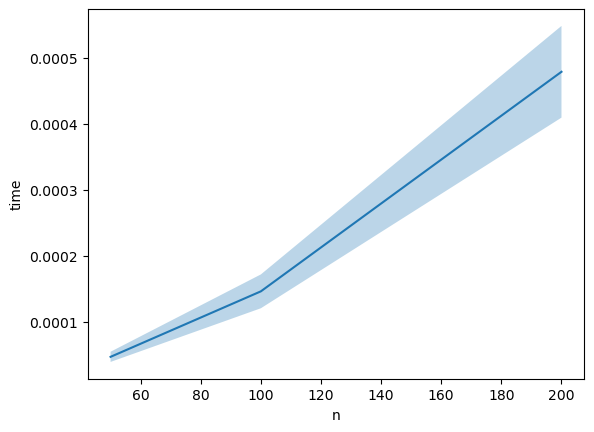

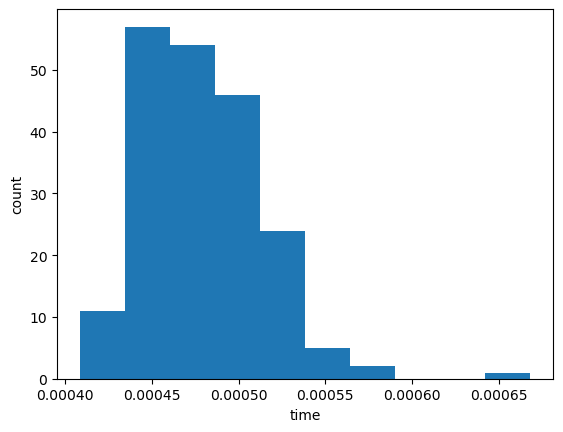

In [3]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro

def max_weight(n):
    a = []
    for _ in range(n):
        s = random.randint(0, 10)
        e = s + random.randint(1, 10)
        w = random.randint(1, 10)
        a.append((s, e, w))

    time_start = time.perf_counter()
    a.sort(key=lambda x: x[1])
    n = len(a)
    dp = [0] * (n + 1)
    for i in range(1, n + 1):
        start, end, weight = a[i - 1]
        j = 0
        for k in range(i - 1, 0, -1):
            if a[k - 1][1] <= start:
                j = k
                break
        dp[i] = max(dp[i - 1], dp[j] + weight)

    time_end = time.perf_counter() - time_start
    return time_end, dp[n]

MO = []
SKO = []
sizes = [50, 100, 200]

for n in sizes:
    times = []
    for _ in range(200):
        t, weight = max_weight(n)
        times.append(t)
    print(f'n={n}, максимальный вес: {weight}')
    MO.append(np.mean(times))
    SKO.append(np.std(times))

plt.plot(sizes, MO)
plt.fill_between(
    sizes,
    np.array(MO) - 2 * np.array(SKO),
    np.array(MO) + 2 * np.array(SKO),
    alpha=0.3
)
plt.xlabel("n")
plt.ylabel("time")
plt.show()

plt.hist(times, bins=10)
plt.xlabel("time")
plt.ylabel("count")
plt.show()